# Loading and Visualization

In this section, we illustrate how to load and visualize the pseudoPAGES2k dataset with `cfr`.

Required data to complete this tutorial:

- pseudoPAGES2k: [ppwn_SNRinf_rta.nc](https://github.com/fzhu2e/paper-pseudoPAGES2k/raw/main/data/ppwn_SNRinf_rta.nc)

In [39]:
%load_ext autoreload
%autoreload 2

%pip install cartopy
%pip install cfr
%pip install requests
%pip install nbformat>=4.2.0

import cfr
print(cfr.__version__)
import xarray as xr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
2026.6.25.14


## Load the pseudoPAGES2k dataset with `xarray`

By default, we may load a netCDF file with `xarray` to have a check of the data structure:

In [4]:
ds = xr.open_dataset('./data/ppwn_SNRinf_rta.nc', use_cftime=True)
ds

<xarray.Dataset> Size: 5MB
Dimensions:  (time: 1156)
Coordinates:
  * time     (time) object 9kB 0850-01-01 00:00:00 ... 2005-01-01 00:00:00
Data variables: (12/558)
    NAm_153  (time) float64 9kB ...
    NAm_165  (time) float64 9kB ...
    Asi_178  (time) float64 9kB ...
    Asi_174  (time) float64 9kB ...
    Asi_198  (time) float64 9kB ...
    NAm_145  (time) float64 9kB ...
    ...       ...
    Ocn_169  (time) float64 9kB ...
    Asi_201  (time) float64 9kB ...
    Asi_179  (time) float64 9kB ...
    Arc_014  (time) float64 9kB ...
    Ocn_071  (time) float64 9kB ...
    Ocn_072  (time) float64 9kB ...

In [28]:
ds['NAm_001']

<xarray.DataArray 'NAm_001' (time: 1156)> Size: 9kB
array([1.066368, 0.867417, 0.871854, ...,      nan,      nan,      nan],
      shape=(1156,))
Coordinates:
  * time     (time) object 9kB 0850-01-01 00:00:00 ... 2005-01-01 00:00:00
Attributes:
    lat:         35.3
    lon:         248.6
    elev:        nan
    ptype:       tree.TRW
    dt:          1.0
    time_name:   Time
    time_unit:   yr
    value_name:  trsgi
    value_unit:  NA

We see that this netCDF file has multiple data variables named after **proxy IDs**.
Each variable comes with the below fundamental attributes:

- lat: the latitude of the site
- lon: the longitude of the site
- ptype: the proxy type
- dt: step of the time axis, i.e., temporal resolution
- time_name: name of the time axis
- time_unit: unit of the time axis
- value_name: unit of the value axis
- value_unit: unit of the value axis

With this certain format, the netCDF file is `cfr` ready.

## Load the pseudoPAEGS2k dataset with `cfr`

The `cfr.ProxyDatabase` class comes with a `.load_nc()` method that can help us load a proxy database from a netCDF file following the certain format shown above:

In [6]:
# load the pseudoPAGES2k database from a netCDF file

# load from a local copy
pdb = cfr.ProxyDatabase().load_nc('./data/ppwn_SNRinf_rta.nc')

# load from the cloud
# pdb = cfr.ProxyDatabase().fetch('pseudoPAGES2k/ppwn_SNRinf_rta')

## Visualize the pseudoPAGES2k dataset

Once the netCDF file is loaded as a `cfr.ProxyDatabase`, we can easily visualize the dataset with the `.plot()` method:

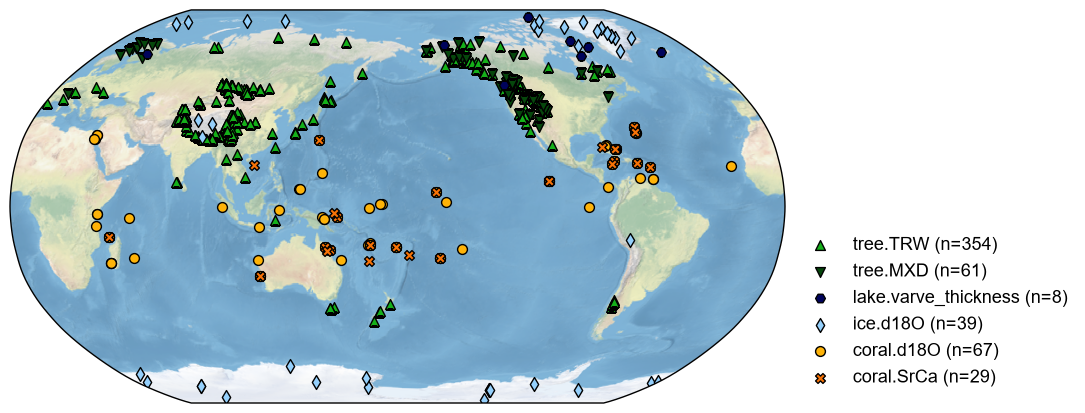

In [7]:
fig, ax = pdb.plot()

We may also plot map along with the count of the records:

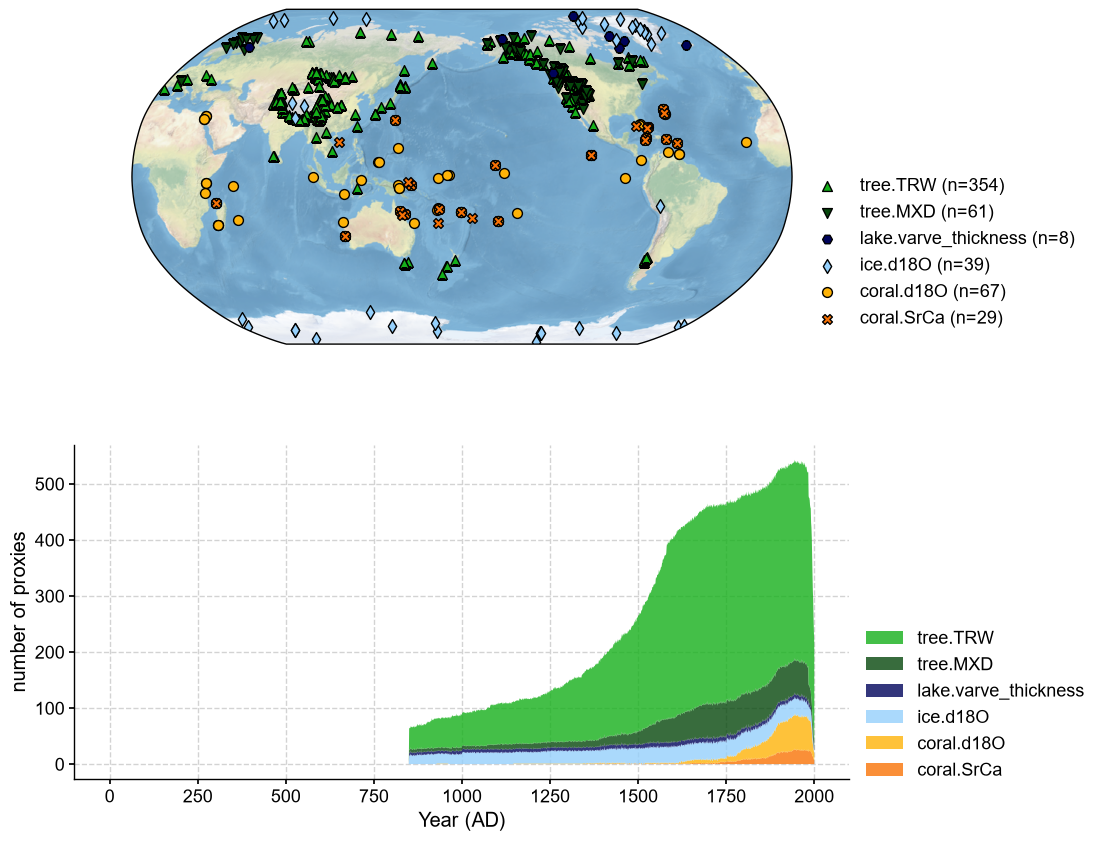

In [8]:
fig, ax = pdb.plot(plot_count=True)

Since the dataset starts from 850 AD, we may adjust the x-axis utilizing the `matplotlib` methods:

(800.0, 2000.0)

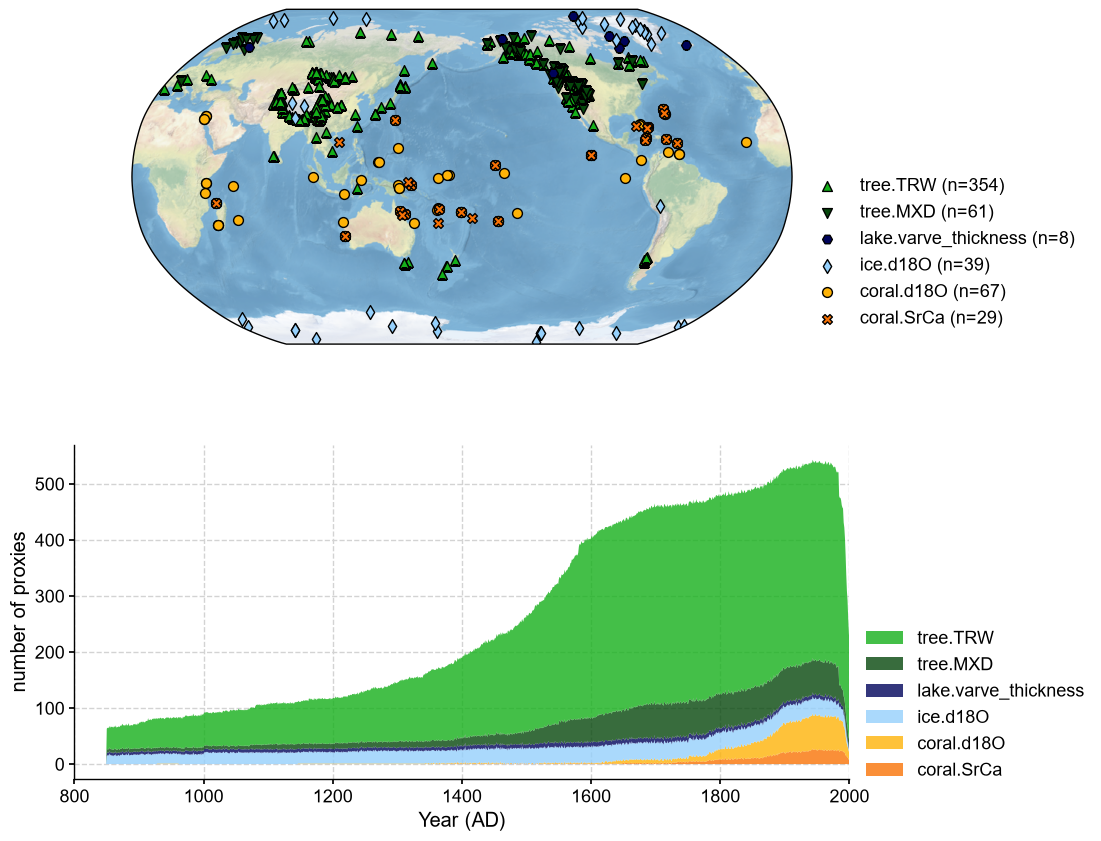

In [9]:
fig, ax = pdb.plot(plot_count=True)
ax['count'].set_xlim(800, 2000)

## Access and visualize a specific record

A specific record can be accessed by its **proxy ID**:

In [29]:
pobj = pdb['NAm_001']
pobj

This returned object is defined by `cfr.ProxyRecord`, which comes with several attributes such as:
- time: the time axis
- value: the value axis
- lat: the latitude of the site
- lon: the longitude of the site
- (... other metadata)

For instance, to access the record series:

In [18]:
print('time axis:', pobj.time)
print('value axis:', pobj.value)

time axis: [1508. 1509. 1510. 1511. 1512. 1513. 1514. 1515. 1516. 1517. 1518. 1519.
 1520. 1521. 1522. 1523. 1524. 1525. 1526. 1527. 1528. 1529. 1530. 1531.
 1532. 1533. 1534. 1535. 1536. 1537. 1538. 1539. 1540. 1541. 1542. 1543.
 1544. 1545. 1546. 1547. 1548. 1549. 1550. 1551. 1552. 1553. 1554. 1555.
 1556. 1557. 1558. 1559. 1560. 1561. 1562. 1563. 1564. 1565. 1566. 1567.
 1568. 1569. 1570. 1571. 1572. 1573. 1574. 1575. 1576. 1577. 1578. 1579.
 1580. 1581. 1582. 1583. 1584. 1585. 1586. 1587. 1588. 1589. 1590. 1591.
 1592. 1593. 1594. 1595. 1596. 1597. 1598. 1599. 1600. 1601. 1602. 1603.
 1604. 1605. 1606. 1607. 1608. 1609. 1610. 1611. 1612. 1613. 1614. 1615.
 1616. 1617. 1618. 1619. 1620. 1621. 1622. 1623. 1624. 1625. 1626. 1627.
 1628. 1629. 1630. 1631. 1632. 1633. 1634. 1635. 1636. 1637. 1638. 1639.
 1640. 1641. 1642. 1643. 1644. 1645. 1646. 1647. 1648. 1649. 1650. 1651.
 1652. 1653. 1654. 1655. 1656. 1657. 1658. 1659. 1660. 1661. 1662. 1663.
 1664. 1665. 1666. 1667. 1668. 1669. 167

Now that we have the `cfr.ProxyRecord` object, we can easily visualize the record utilizing the `.plot()` method:

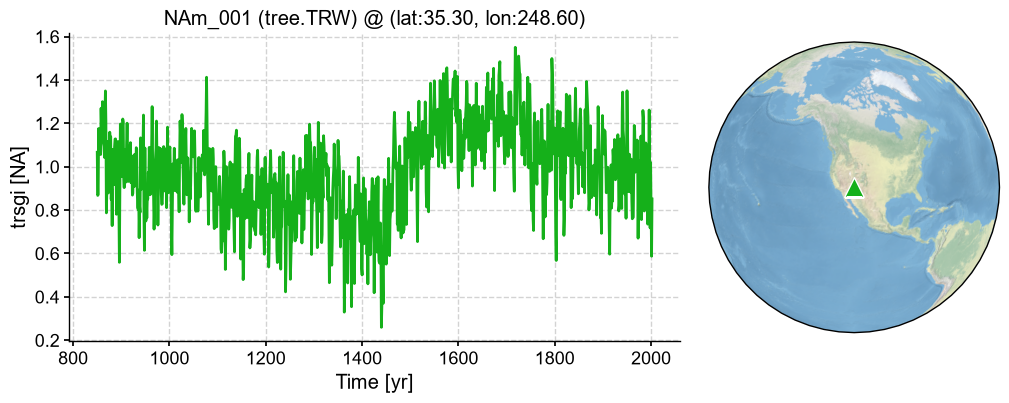

In [30]:
fig, ax = pobj.plot()

We may **slice the record** to zoom in and out.
For instance, let us check the instrumental period:

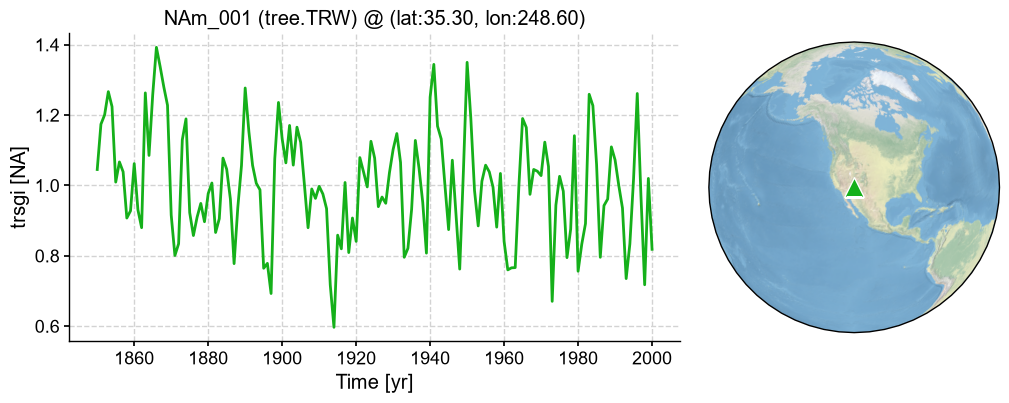

In [31]:
fig, ax = pobj.slice([1850, 2000]).plot()

We may also slice with a shortcut using strings of years:

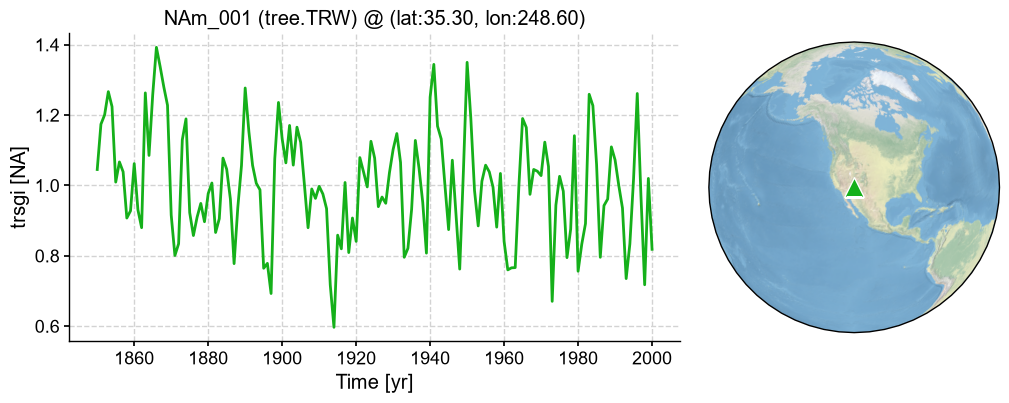

In [32]:
fig, ax = pobj['1850':'2000'].plot()

This shortcut also supports time step.
For instance, to display the data points every 10 years between 1850 AD and 2000 AD:

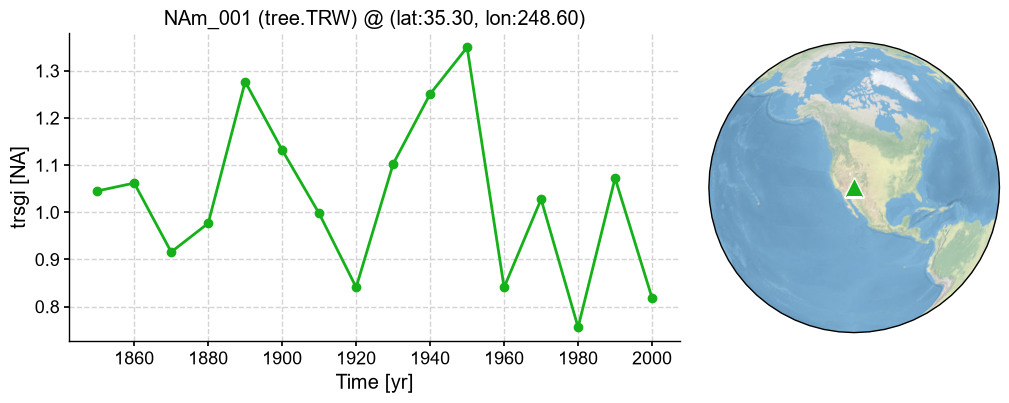

In [33]:
fig, ax = pobj['1850':'2000':'10'].plot(marker='o')

## Check the **proxy IDs** on an interactive map

One may ask "How do I know the proxy IDs?"

A `cfr.ProxyDatabase` object also comes with a `.plotly()` method that can help us check **proxy IDs** on an interactive map.
It will display an interactive map, and by hovering the mouse over each site marker, one may check the metadata of a specific site, including:

- pid (proxy ID)
- ptype
- lat
- lon

In [ ]:
pdb.plotly()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hoverinfo': 'lon+lat',
              'hovertemplate': ('<br>pid: %{hovertext}</br>ptyp' ... '/br>lat: %{lat}<extra></extra>'),
              'hovertext': array(['NAm_153', 'Asi_178', 'Asi_174', ..., 'Asi_026', 'Asi_201', 'Asi_179'],
                                 shape=(354,), dtype=object),
              'lat': array([np.float64(52.7), np.float64(28.77), np.float64(28.18), ...,
                            np.float64(27.67), np.float64(35.88), np.float64(27.5)],
                           shape=(354,), dtype=object),
              'lon': array([np.float64(241.7), np.float64(83.73), np.float64(85.43), ...,
                            np.float64(90.73), np.float64(74.18), np.float64(88.02)],
                           shape=(354,), dtype=object),
              'marker': {'color': '#15b01a',
                         'line': {'color': 'black', 'width': 0.5},
                         'size': 10,
                         'symbol': 'triangle-up'},
              'name': 'tree.TRW (n=354)',
              'text': 'tree.TRW',
              'type': 'scattergeo'},
             {'hoverinfo': 'lon+lat',
              'hovertemplate': ('<br>pid: %{hovertext}</br>ptyp' ... '/br>lat: %{lat}<extra></extra>'),
              'hovertext': array(['NAm_165', 'Arc_071', 'NAm_102', 'NAm_194', 'NAm_086', 'NAm_122',
                                  'NAm_134', 'NAm_123', 'NAm_113', 'NAm_124', 'NAm_115', 'NAm_103',
                                  'Eur_013', 'NAm_130', 'NAm_104', 'NAm_175', 'NAm_181', 'NAm_095',
                                  'NAm_106', 'NAm_116', 'NAm_084', 'NAm_184', 'Arc_066', 'Eur_003',
                                  'NAm_187', 'Eur_007', 'NAm_026', 'Arc_063', 'NAm_141', 'Arc_077',
                                  'Arc_065', 'NAm_107', 'NAm_185', 'NAm_150', 'NAm_192', 'NAm_199',
                                  'NAm_152', 'NAm_121', 'NAm_139', 'NAm_167', 'Arc_074', 'NAm_179',
                                  'NAm_118', 'NAm_041', 'NAm_174', 'NAm_197', 'NAm_169', 'NAm_119',
                                  'NAm_064', 'NAm_164', 'NAm_131', 'Arc_068', 'NAm_200', 'Arc_062',
                                  'NAm_172', 'NAm_202', 'NAm_137', 'NAm_204', 'NAm_108', 'NAm_101',
                                  'NAm_143'], dtype=object),
              'lat': array([np.float64(37.9), np.float64(68.49166667), np.float64(62.0),
                            np.float64(48.7), np.float64(61.8), np.float64(51.8), np.float64(50.2),
                            np.float64(49.4), np.float64(62.7), np.float64(49.2), np.float64(56.2),
                            np.float64(67.0), np.float64(62.0), np.float64(55.3), np.float64(68.7),
                            np.float64(44.8), np.float64(45.9), np.float64(62.4), np.float64(35.4),
                            np.float64(61.7), np.float64(63.7), np.float64(43.0), np.float64(65.9),
                            np.float64(68.0), np.float64(37.6), np.float64(46.4), np.float64(51.4),
                            np.float64(63.2475), np.float64(50.7), np.float64(66.6),
                            np.float64(66.3), np.float64(32.5), np.float64(45.3), np.float64(51.1),
                            np.float64(46.2), np.float64(41.3), np.float64(52.2), np.float64(52.3),
                            np.float64(49.7), np.float64(39.3), np.float64(68.73), np.float64(45.8),
                            np.float64(54.9), np.float64(39.9), np.float64(44.6), np.float64(44.2),
                            np.float64(38.7), np.float64(53.3), np.float64(44.4), np.float64(40.1),
                            np.float64(52.3), np.float64(65.2), np.float64(44.8), np.float64(68.26),
                            np.float64(43.9), np.float64(43.7), np.float64(50.6), np.float64(41.4),
                            np.float64(37.8), np.float64(65.2), np.float64(69.5)], dtype=object),
              'lon': array([np.float64(252.3), np.float64(27.33333333), np.float64(218.0),
                            np.float64